<a href="https://colab.research.google.com/github/RicoRonald/RicoRonaldM_G.231.23.0128TransformasiCitra/blob/main/implementasi_analisis_citra_sederhana_opencv_pillow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import shutil
import random

# 1. Download dataset
path = kagglehub.dataset_download("mhmmadalewi/buildings-vs-forests")
print("Path asal dataset:", path)

# 2. Folder tujuan
target_dir = "/content/Buildings-vs-Forests-dataset"
n_total_desired = 500  # Sekarang diatur ke 500 gambar

# 3. Identifikasi folder kategori
categories = ['buildings', 'forests']
n_per_category = n_total_desired // len(categories)

# Buat folder utama jika belum ada
os.makedirs(target_dir, exist_ok=True)

for category in categories:
    # Cari path kategori secara rekursif
    source_cat_path = None
    for root, dirs, files in os.walk(path):
        # Mengecek apakah nama folder mengandung kategori
        for d in dirs:
            if category.lower() == d.lower():
                source_cat_path = os.path.join(root, d)
                break
        if source_cat_path: break

    if source_cat_path is None:
        print(f"Peringatan: Folder kategori '{category}' tidak ditemukan!")
        continue

    dest_cat_path = os.path.join(target_dir, category)
    os.makedirs(dest_cat_path, exist_ok=True)

    # Ambil daftar file gambar
    all_images = [f for f in os.listdir(source_cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not all_images:
        print(f"Peringatan: Tidak ada gambar ditemukan di {source_cat_path}")
        continue

    # Ambil sampel acak sesuai jumlah yang diinginkan
    jumlah_diambil = min(n_per_category, len(all_images))
    sample_images = random.sample(all_images, jumlah_diambil)

    # Copy file ke folder baru
    for img in sample_images:
        shutil.copy(os.path.join(source_cat_path, img), os.path.join(dest_cat_path, img))

print(f"\nSelesai! Gambar telah disiapkan di: {target_dir}")
print("Distribusi per kategori:")
for cat in categories:
    cat_path = os.path.join(target_dir, cat)
    if os.path.exists(cat_path):
        count = len(os.listdir(cat_path))
        print(f"- {cat}: {count} gambar")

Using Colab cache for faster access to the 'buildings-vs-forests' dataset.
Path asal dataset: /kaggle/input/buildings-vs-forests
Peringatan: Folder kategori 'forests' tidak ditemukan!

Selesai! Gambar telah disiapkan di: /content/Buildings-vs-Forests-dataset
Distribusi per kategori:
- buildings: 250 gambar


In [ ]:
import cv2
import numpy as np
from pathlib import Path

def process_images(input_root, output_root):
    input_path = Path(input_root)
    output_path = Path(output_root)

    # Mendapatkan semua file gambar
    image_files = list(input_path.glob('**/*.jpg')) + list(input_path.glob('**/*.png'))
    print(f"Ditemukan {len(image_files)} gambar untuk diproses.")

    for img_path in image_files:
        # 1. Baca Gambar
        img = cv2.imread(str(img_path))
        if img is None: continue

        # 2. Konversi Warna: BGR ke HSV
        hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # 3. Filtering: Median Blur (Kernel 5x5)
        processed_img = cv2.medianBlur(hsv_img, 5)

        # 4. Tentukan path output
        relative_path = img_path.relative_to(input_path)
        save_path = output_path / relative_path
        save_path.parent.mkdir(parents=True, exist_ok=True)

        # 5. Simpan
        cv2.imwrite(str(save_path), processed_img)

    print(f"Pemrosesan selesai! Hasil disimpan di: {output_root}")

# Eksekusi Script menggunakan folder baru
input_folder = "/content/Buildings-vs-Forests-dataset"
output_folder = "/content/dataset_processed"
process_images(input_folder, output_folder)

Ditemukan 250 gambar untuk diproses.
Pemrosesan selesai! Hasil disimpan di: /content/dataset_processed


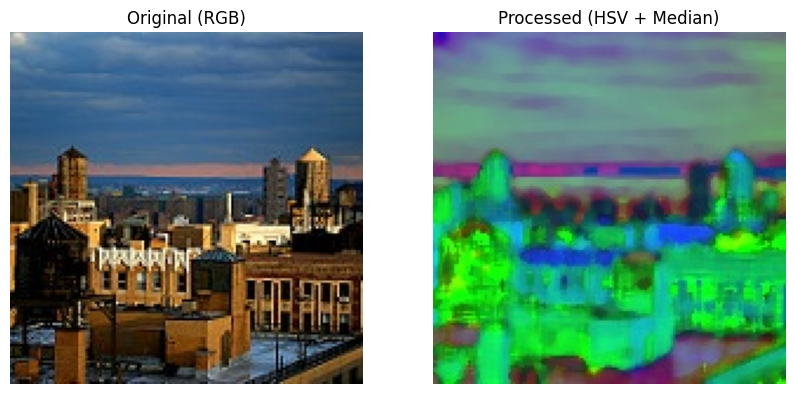

In [ ]:
import matplotlib.pyplot as plt
import os

# Visualisasi Perbandingan
def visualize_sample(original_path, processed_path):
    if not os.path.exists(original_path):
        print("File original tidak ditemukan!")
        return

    orig = cv2.cvtColor(cv2.imread(original_path), cv2.COLOR_BGR2RGB)
    proc = cv2.imread(processed_path)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original (RGB)")
    plt.imshow(orig)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Processed (HSV + Median)")
    plt.imshow(proc)
    plt.axis('off')
    plt.show()

# Ambil satu contoh
base_path = "/content/Buildings-vs-Forests-dataset/buildings"
sample_name = os.listdir(base_path)[0]
visualize_sample(
    f"{base_path}/{sample_name}",
    f"/content/dataset_processed/buildings/{sample_name}"
)